In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load the dataset

df = pd.read_csv("datafile (1).csv")

# Display the first 5 rows
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,ARHAR,Uttar Pradesh,9794.05,23076.74,1941.55,9.83
1,ARHAR,Karnataka,10593.15,16528.68,2172.46,7.47
2,ARHAR,Gujarat,13468.82,19551.90,1898.30,9.59
3,ARHAR,Andhra Pradesh,17051.66,24171.65,3670.54,6.42
4,ARHAR,Maharashtra,17130.55,25270.26,2775.80,8.72


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 6 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Crop                                   49 non-null     str    
 1   State                                  49 non-null     str    
 2   Cost of Cultivation (`/Hectare) A2+FL  49 non-null     float64
 3   Cost of Cultivation (`/Hectare) C2     49 non-null     float64
 4   Cost of Production (`/Quintal) C2      49 non-null     float64
 5   Yield (Quintal/ Hectare)               49 non-null     float64
dtypes: float64(4), str(2)
memory usage: 2.4 KB


,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
count,49.000000,49.000000,49.000000,49.000000
mean,20363.537347,31364.666735,1620.537755,98.086735
std,13561.435306,20095.783569,1104.990472,245.293123
min,5483.540000,7868.640000,85.790000,1.320000
25%,12774.410000,19259.840000,732.620000,9.590000
50%,17022.000000,25909.050000,1595.560000,13.700000
75%,24731.060000,35423.480000,2228.970000,36.610000
max,66335.060000,91442.630000,5777.480000,1015.450000


In [5]:
df.isnull().sum()

Crop                                     0
State                                    0
Cost of Cultivation (`/Hectare) A2+FL    0
Cost of Cultivation (`/Hectare) C2       0
Cost of Production (`/Quintal) C2        0
Yield (Quintal/ Hectare)                 0
dtype: int64

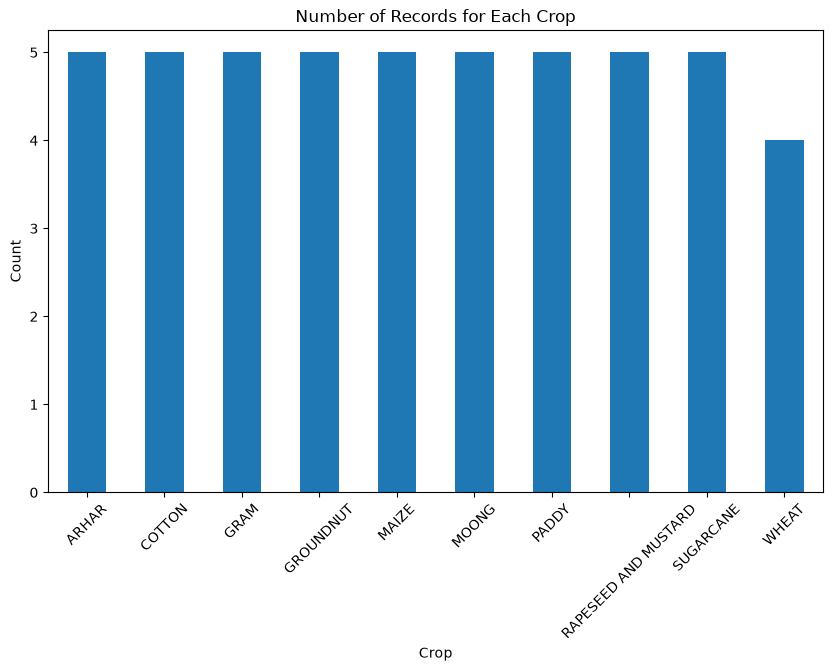

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df["Crop"].value_counts().plot(kind="bar")
plt.title("Number of Records for Each Crop")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [8]:
print(df.columns)

Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare) '],
      dtype='str')


In [9]:
# Remove extra spaces from all column names
df.columns = df.columns.str.strip()

In [10]:
print(df.columns)

Index(['Crop', 'State', 'Cost of Cultivation (`/Hectare) A2+FL',
       'Cost of Cultivation (`/Hectare) C2',
       'Cost of Production (`/Quintal) C2', 'Yield (Quintal/ Hectare)'],
      dtype='str')


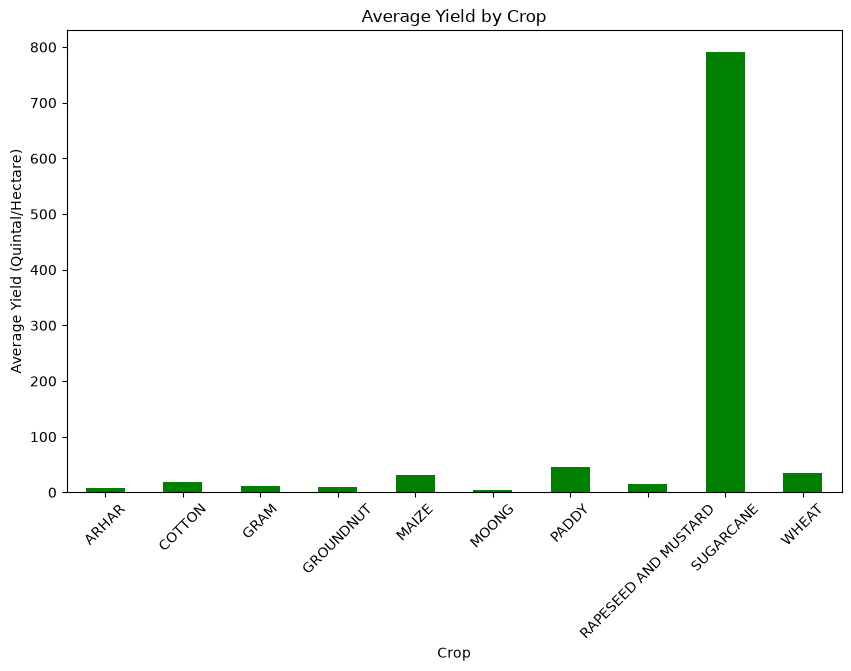

In [11]:
plt.figure(figsize=(10,6))

df.groupby("Crop")["Yield (Quintal/ Hectare)"].mean().plot(
    kind="bar",
    color="green"
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Quintal/Hectare)")
plt.xticks(rotation=45)

plt.show()

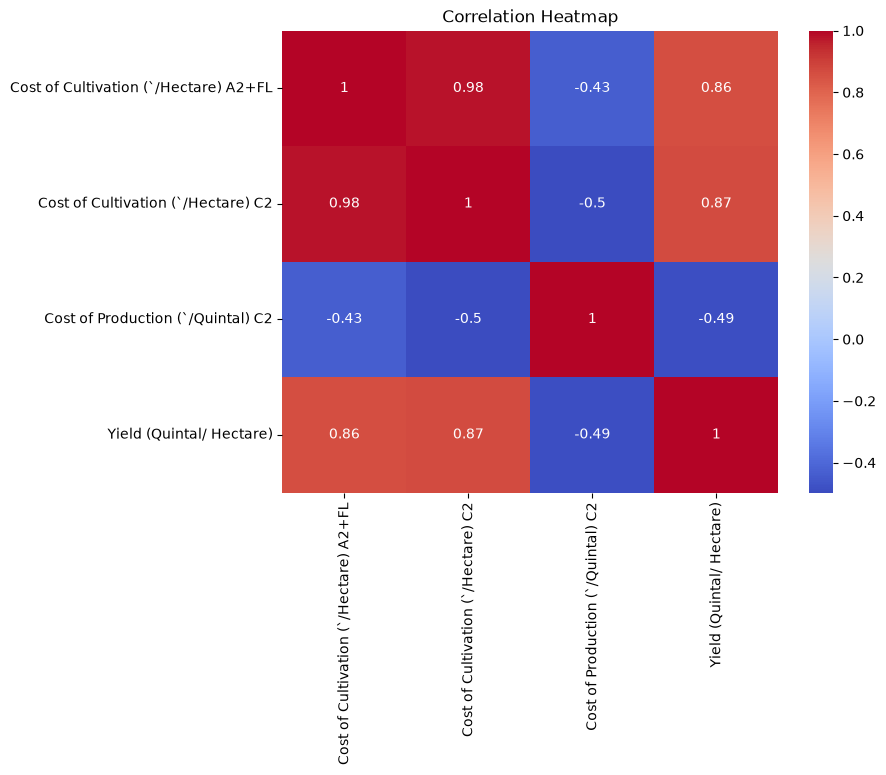

In [12]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le_crop = LabelEncoder()
le_state = LabelEncoder()

# Convert text into numbers
df["Crop"] = le_crop.fit_transform(df["Crop"])
df["State"] = le_state.fit_transform(df["State"])

# Display first 5 rows
df.head()

,Crop,State,Cost of Cultivation (`/Hectare) A2+FL,Cost of Cultivation (`/Hectare) C2,Cost of Production (`/Quintal) C2,Yield (Quintal/ Hectare)
0,0,11,9794.05,23076.74,1941.55,9.83
1,0,4,10593.15,16528.68,2172.46,7.47
2,0,2,13468.82,19551.90,1898.30,9.59
3,0,0,17051.66,24171.65,3670.54,6.42
4,0,6,17130.55,25270.26,2775.80,8.72


In [14]:
# Input features
X = df.drop("Yield (Quintal/ Hectare)", axis=1)

# Output (Target)
y = df["Yield (Quintal/ Hectare)"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (49, 5)
Target Shape: (49,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (39, 5)
Testing Data: (10, 5)


In [16]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
y_pred = model.predict(X_test)

print(y_pred)

[  8.9099  49.7925  46.855  797.3447  16.3884   6.3088   7.2594   6.8473
  38.1995  14.3888]


In [18]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 28.431489999999997
R2 Score: 0.9462833313407573


In [19]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)

    Actual  Predicted
0     8.05     8.9099
1    23.59    49.7925
2    34.99    46.8550
3  1015.45   797.3447
4    11.98    16.3884
5     1.32     6.3088
6     4.05     7.2594
7     3.01     6.8473
8    32.42    38.1995
9     9.33    14.3888


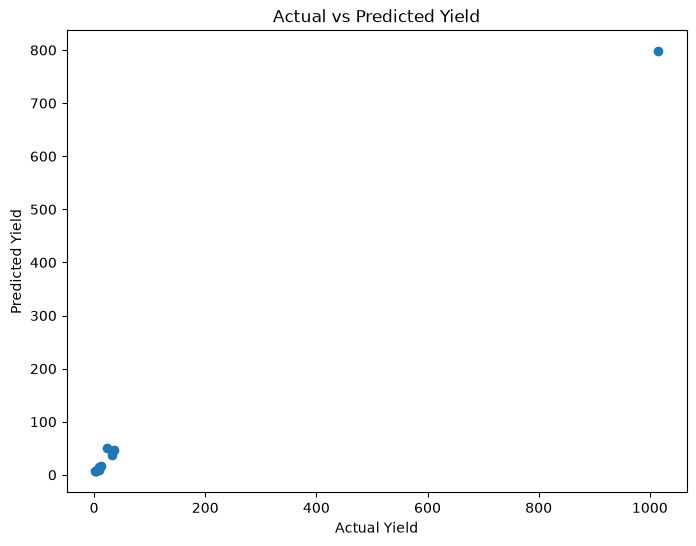

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")

plt.show()